In [2]:
import pandas as pd
import numpy as np

# --- ZADANIE 1 ---
df_original = pd.read_csv('zamowienia.csv', sep=';')
print("Braki w oryginale:\n", df_original.isnull().sum())

Braki w oryginale:
 Kraj               0
Sprzedawca         0
Data zamowienia    0
idZamowienia       0
Utarg              0
dtype: int64


In [3]:
df_missing = df_original.copy()

df_missing.loc[df_missing.sample(frac=0.10).index, 'Sprzedawca'] = 'BRAK'
df_missing.loc[df_missing.sample(frac=0.05).index, 'idZamowienia'] = np.nan
df_missing.loc[df_missing.sample(frac=0.20).index, 'Data zamowienia'] = np.nan
df_missing.loc[df_missing.sample(frac=0.15).index, 'Utarg'] = np.nan

print("\nBraki po Zadaniu 1:\n", df_missing.isnull().sum())


Braki po Zadaniu 1:
 Kraj                 0
Sprzedawca           0
Data zamowienia    160
idZamowienia        40
Utarg              120
dtype: int64


In [4]:
# --- ZADANIE 2 ---
df_missing['idZamowienia'] = df_missing['idZamowienia'].fillna(0)

df_missing['Data zamowienia'] = df_missing['Data zamowienia'].ffill()

df_missing['Utarg'] = df_missing.groupby('Kraj')['Utarg'].transform(lambda x: x.fillna(x.mean()))

print("\nBraki po Zadaniu 2:\n", df_missing.isnull().sum())


Braki po Zadaniu 2:
 Kraj               0
Sprzedawca         0
Data zamowienia    4
idZamowienia       0
Utarg              0
dtype: int64


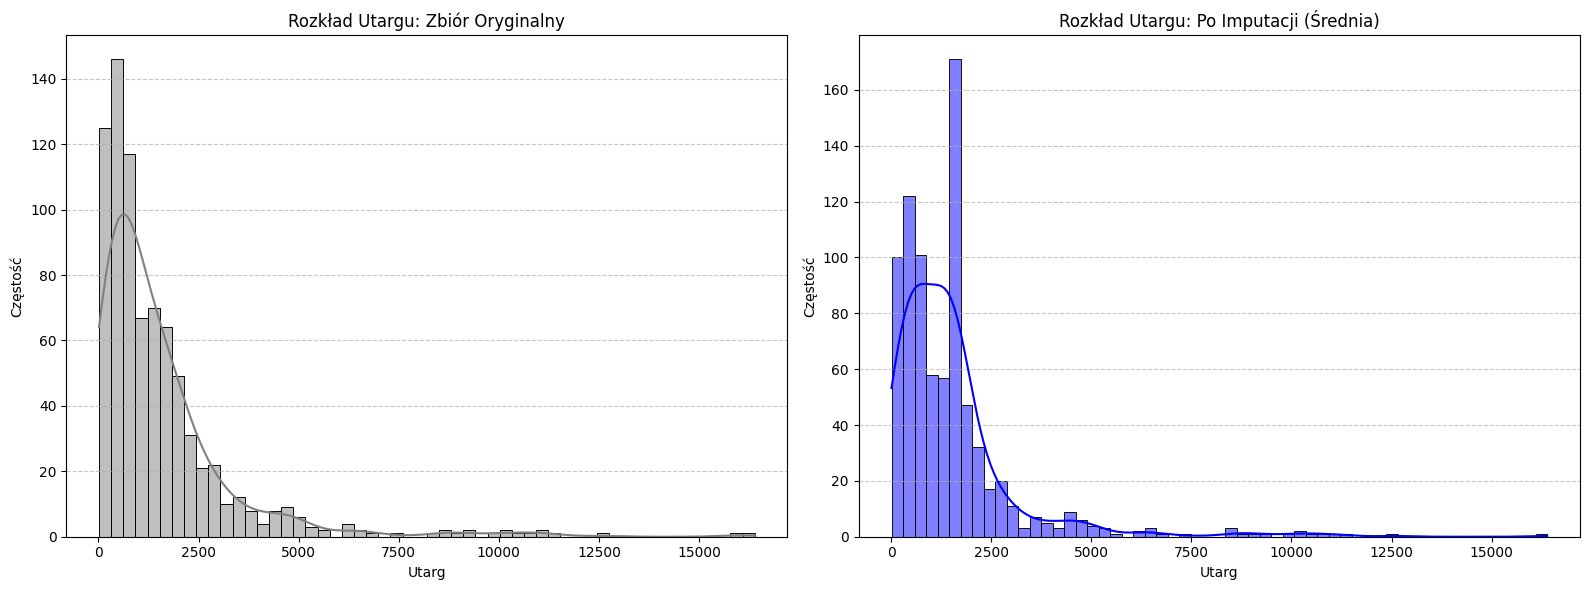

In [8]:
# --- ZADANIE 3 ---
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df_original['Utarg'], kde=True, ax=ax1, color='gray', label='Oryginał')
ax1.set_title("Rozkład Utargu: Zbiór Oryginalny")
ax1.set_xlabel("Utarg")
ax1.set_ylabel("Częstość")
ax1.grid(axis='y', linestyle='--', alpha=0.7)
sns.histplot(df_missing['Utarg'], kde=True, ax=ax2, color='blue', label='Po Imputacji')
ax2.set_title("Rozkład Utargu: Po Imputacji (Średnia)")
ax2.set_xlabel("Utarg")
ax2.set_ylabel("Częstość")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [10]:
# --- ZADANIE 4 ---

from sklearn.impute import KNNImputer
df_diabetes = pd.read_csv('Diabetes Missing Data.csv')

In [11]:
def kategoryzuj_wiek(age):
    if age < 18: return '<18'
    elif 18 <= age <= 29: return '18_29'
    elif 30 <= age <= 49: return '30_49'
    else: return '50+'

df_diabetes['Age_Group'] = df_diabetes['Age'].apply(kategoryzuj_wiek)

print("Liczba osób w grupach wiekowych:")
print(df_diabetes['Age_Group'].value_counts())

Liczba osób w grupach wiekowych:
Age_Group
18_29    396
30_49    283
50+       89
Name: count, dtype: int64


In [12]:
def imputuj_knn_w_grupie(group):
    num_cols = group.select_dtypes(include=[np.number]).columns

    imputer = KNNImputer(n_neighbors=5)
    group[num_cols] = imputer.fit_transform(group[num_cols])
    return group

df_class_imputed = df_diabetes.groupby('Class', group_keys=False).apply(imputuj_knn_w_grupie)

df_age_imputed = df_diabetes.groupby('Age_Group', group_keys=False).apply(imputuj_knn_w_grupie)


Imputacja zakończona pomyślnie!


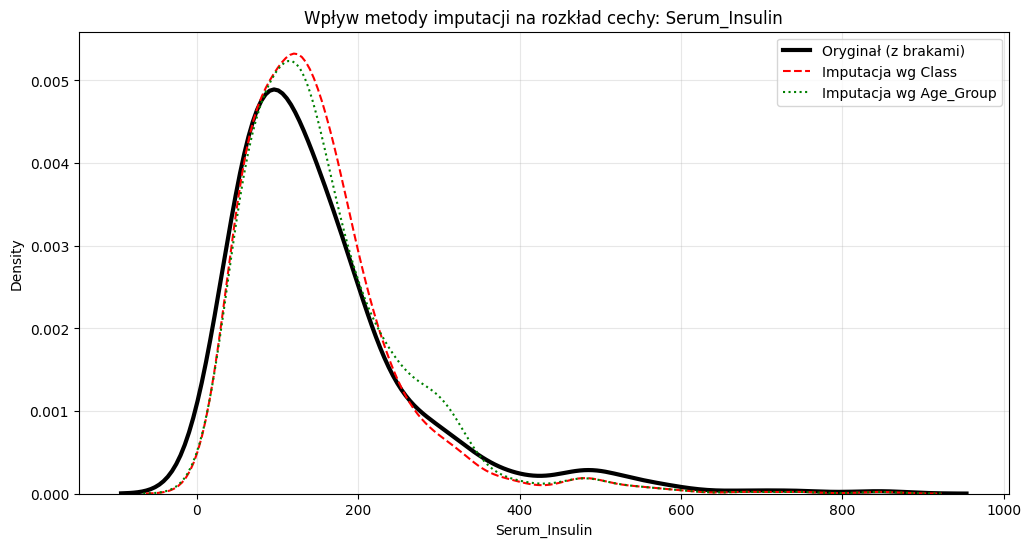

In [13]:
cecha = 'Serum_Insulin'

plt.figure(figsize=(12, 6))

sns.kdeplot(df_diabetes[cecha].dropna(), label='Oryginał (z brakami)', color='black', lw=3)

# Po imputacji grupami Class
sns.kdeplot(df_class_imputed[cecha], label='Imputacja wg Class', color='red', linestyle='--')

sns.kdeplot(df_age_imputed[cecha], label='Imputacja wg Age_Group', color='green', linestyle=':')

plt.title(f"Wpływ metody imputacji na rozkład cechy: {cecha}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()